## **Introduction**

- **Nama**  : Derida Elfraim Falahian
- **Batch** : HCK-040 

##### **URL Dataset:** https://www.kaggle.com/datasets/kaggle/us-consumer-finance-complaints

##### **Problem:**  
Perusahaan jasa keuangan menerima ribuan keluhan pelanggan setiap hari. Sebagian keluhan dapat diselesaikan dengan baik, namun sebagian lainnya berakhir menjadi sengketa (consumer dispute). Proses penanganan sengketa membutuhkan biaya, waktu, dan sumber daya tambahan.

Project ini bertujuan membangun model machine learning untuk mengidentifikasi kemungkinan terjadinya sengketa sejak keluhan pertama kali diterima
1. **Specific**     : Membangun model machine learning untuk memprediksi apakah suatu keluhan konsumen terhadap perusahaan jasa keuangan
akan berakhir pada status *disputed* atau *non-disputed* berdasarkan atribut-atributnya.
2. **Measurable**   : Mendapatkan model dengan performa *f1-score* >= 75% dan *ROC-AUC-score* >= 0.8
3. **Achievable**   : Dataset memiliki lebih dari 500.000 data historis keluhan konsumen sehingga cukup untuk melatih berbagai algoritma yang telah ditentukan
4. **Relevant**     : Dengan memprediksi potensi sengketa sejak awal, perusahaan dapat melakukan tindakan preventif terhadap kasus yang berisiko tinggi.
5. **Time Bound**   : Model akan dikembangkan, dievaluasi, dan dideploy dalam periode pengerjaan Milestone 2 dengan memanfaatkan data historis

#### **User:**  Perusahaan Jasa Keuangan yang ini mengecek apakah sebuah komplain dari customer bisa berujung pada status sengeta.

##### **Objective**
1. Mengembangkan sistem prediksi sengketa pelanggan yang dapat membantu perusahaan jasa keuangan mengidentifikasi keluhan berisiko tinggi sehingga proses penanganan dapat diprioritaskan secara lebih efektif dan efisien.
2. Membangun model klasifikasi yang mampu memprediksi status consumer disputed berdasarkan informasi keluhan pelanggan dengan performa terbaik melalui evaluasi beberapa algoritma machine learning, cross validation, dan hyperparameter tuning.

## **Library**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import kagglehub

from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from feature_engine.outliers import Winsorizer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import joblib
import warnings

warnings.filterwarnings('ignore')

ModuleNotFoundError: No module named 'pandas'

## **Data Loading**

In [ ]:
path = kagglehub.dataset_download("kaggle/us-consumer-finance-complaints")

print("Path downloaded:", path)
print("Files available:", os.listdir(path))

# Load CSV dari path yang didownload
df = pd.read_csv(os.path.join(path, "consumer_complaints.csv"))
df = df.head(100000)
print(df.shape)

Path downloaded: C:\Users\Derida21\.cache\kagglehub\datasets\kaggle\us-consumer-finance-complaints\versions\2
Files available: ['consumer_complaints.csv', 'database.sqlite']
(50000, 18)


In [3]:
df.head()

,date_received,product,sub_product,issue,sub_issue,consumer_complaint_narrative,company_public_response,company,state,zipcode,tags,consumer_consent_provided,submitted_via,date_sent_to_company,company_response_to_consumer,timely_response,consumer_disputed?,complaint_id
0,08/30/2013,Mortgage,Other mortgage,"Loan modification,collection,foreclosure",NaN,NaN,NaN,U.S. Bancorp,CA,95993,NaN,NaN,Referral,09/03/2013,Closed with explanation,Yes,Yes,511074
1,08/30/2013,Mortgage,Other mortgage,"Loan servicing, payments, escrow account",NaN,NaN,NaN,Wells Fargo & Company,CA,91104,NaN,NaN,Referral,09/03/2013,Closed with explanation,Yes,Yes,511080
2,08/30/2013,Credit reporting,NaN,Incorrect information on credit report,Account status,NaN,NaN,Wells Fargo & Company,NY,11764,NaN,NaN,Postal mail,09/18/2013,Closed with explanation,Yes,No,510473
3,08/30/2013,Student loan,Non-federal student loan,Repaying your loan,Repaying your loan,NaN,NaN,"Navient Solutions, Inc.",MD,21402,NaN,NaN,Email,08/30/2013,Closed with explanation,Yes,Yes,510326
4,08/30/2013,Debt collection,Credit card,False statements or representation,Attempted to collect wrong amount,NaN,NaN,Resurgent Capital Services L.P.,GA,30106,NaN,NaN,Web,08/30/2013,Closed with explanation,Yes,Yes,511067


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
complaint_id,50000.0,659058.6623,68620.280747,509944.0,604907.0,666034.0,716442.75,973575.0


**Insight:**
Didapatkan bahwa hanya terdeteksi hanya 1 column numerik, sehingga pada proses data manipuation akan dilakukan proses penyesuaian type data

In [5]:
# cek missing value
print(df.isna().sum())
print(f'\nTotal Missing Value: {df.isna().sum().sum()}')

date_received                       0
product                             0
sub_product                     13242
issue                               0
sub_issue                       27545
consumer_complaint_narrative    50000
company_public_response         49992
company                             0
state                             157
zipcode                           157
tags                            42805
consumer_consent_provided       50000
submitted_via                       0
date_sent_to_company                0
company_response_to_consumer        0
timely_response                     0
consumer_disputed?                  0
complaint_id                        0
dtype: int64

Total Missing Value: 233898


**Insight:**  
* Dataset berisi **555.957 keluhan konsumen**, sehingga cukup besar dan representatif untuk analisis maupun Machine Learning.
* Sebagian besar fitur bertipe **kategorikal (17 dari 18 kolom)**, sehingga analisis akan berfokus pada pola kategori dan frekuensi keluhan.
* Beberapa kolom memiliki **missing value tinggi**, terutama `consumer_complaint_narrative`, `tags`, dan `company_public_response`.
* Kolom waktu (`date_received` dan `date_sent_to_company`) lengkap dan dapat digunakan untuk analisis tren keluhan dari waktu ke waktu.
* Tersedia kolom teks (`consumer_complaint_narrative`) yang memungkinkan analisis NLP seperti klasifikasi atau pencarian topik keluhan.
* Informasi seperti **produk, perusahaan, jenis masalah, respons perusahaan, dan status sengketa** dapat digunakan untuk mengidentifikasi faktor yang memengaruhi kepuasan dan penyelesaian keluhan konsumen.


In [6]:
#  Cek total data unik dari setiap kolom
df.nunique()

date_received                     190
product                             9
sub_product                        28
issue                              75
sub_issue                          67
consumer_complaint_narrative        0
company_public_response             3
company                          1396
state                              62
zipcode                         12796
tags                                3
consumer_consent_provided           0
submitted_via                       6
date_sent_to_company              278
company_response_to_consumer        5
timely_response                     2
consumer_disputed?                  2
complaint_id                    50000
dtype: int64

**Insight:**  
* Dataset mencakup **11 jenis produk keuangan** dengan **95 jenis permasalahan (issue)** dan **68 sub-permasalahan**, menunjukkan variasi keluhan yang cukup beragam.
* Terdapat **3.605 perusahaan** yang menerima keluhan, sehingga dataset dapat digunakan untuk membandingkan performa penanganan keluhan antar perusahaan.
* Keluhan berasal dari **62 wilayah (state)** dan **27.052 kode pos**, menandakan cakupan geografis yang luas.
* Kolom `consumer_complaint_narrative` memiliki **65.646 narasi unik**, menunjukkan potensi besar untuk analisis teks (NLP) seperti klasifikasi dan topic modeling.
* Kanal pengaduan (`submitted_via`) hanya terdiri dari **6 kategori**, sehingga dapat dianalisis untuk mengetahui media pelaporan yang paling sering digunakan.
* Kolom `timely_response` dan `consumer_disputed?` masing-masing hanya memiliki **2 kategori**, sehingga sangat cocok dijadikan target pada kasus **binary classification**.
* `complaint_id` memiliki **555.957 nilai unik**, sama dengan jumlah baris data, sehingga berfungsi sebagai **identifier** dan tidak memberikan informasi prediktif untuk analisis maupun pemodelan.


## **Exploratory and Analysis**

,consumer_disputed?,Jumlah
0,No,40375
1,Yes,9625


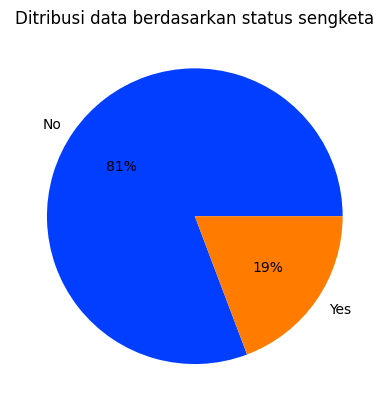

In [7]:
sort = df.groupby('consumer_disputed?').agg(
    Jumlah = ('complaint_id','count')
).reset_index()

display(sort)

colors = sns.color_palette('bright')

plt.title('Ditribusi data berdasarkan status sengketa')
plt.pie(sort.Jumlah,labels= sort['consumer_disputed?'], colors=colors, autopct='%.0f%%')
plt.show()

#### 2. Analisis 10 Company dengan Keluhan Terbanyak

In [8]:
result = (
    df.groupby('company').agg(
        total_complaint=('complaint_id', 'count'),
        product_name=('product', lambda x: x.mode().iloc[0]),
        sub_product_name=('sub_product', lambda x: x.mode().iloc[0] if not x.mode().empty else None),
        total_sub_product = ('sub_product','count')
    ).reset_index().sort_values('total_complaint', ascending=False)
)

result = result.head(10)
result

,company,total_complaint,product_name,sub_product_name,total_sub_product
177,Bank of America,3910,Mortgage,Other mortgage,3403
1359,Wells Fargo & Company,3559,Mortgage,Checking account,3292
465,Experian,3019,Credit reporting,Personal line of credit,17
674,JPMorgan Chase & Co.,2839,Mortgage,Other mortgage,2248
457,Equifax,2653,Credit reporting,Credit card,5
294,Citibank,2170,Credit card,Other mortgage,1194
918,Ocwen,2164,Mortgage,Conventional fixed mortgage,2157
1279,"TransUnion Intermediate Holdings, Inc.",2032,Credit reporting,FHA mortgage,5
886,Nationstar Mortgage,1453,Mortgage,Conventional fixed mortgage,1452
256,Capital One,1240,Credit card,Credit card,483


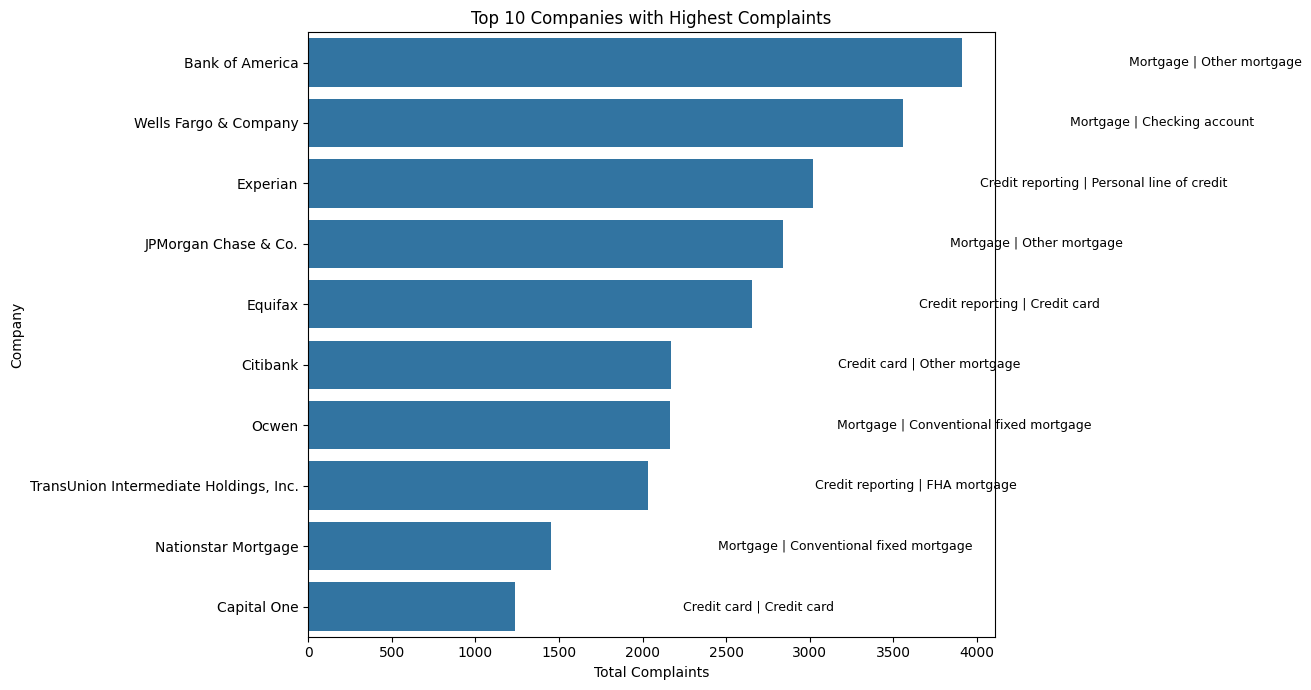

In [9]:
top10 = result.head(10)

plt.figure(figsize=(14,7))

ax = sns.barplot(
    data=top10,
    x='total_complaint',
    y='company'
)

for i, row in enumerate(top10.itertuples()):
    ax.text(
        row.total_complaint + 1000,
        i,
        f"{row.product_name} | {row.sub_product_name}",
        va='center',
        fontsize=9
    )

plt.title('Top 10 Companies with Highest Complaints')
plt.xlabel('Total Complaints')
plt.ylabel('Company')

plt.tight_layout()
plt.show()

**Hasil:**  
* **Bank of America, Wells Fargo, JPMorgan Chase, Ocwen, dan Nationstar Mortgage** didominasi oleh keluhan pada produk **Mortgage**, khususnya sub-produk **Other mortgage**. Hal ini menunjukkan bahwa layanan hipotek merupakan sumber utama keluhan pada perusahaan-perusahaan tersebut.

* **Equifax, Experian, dan TransUnion** didominasi oleh produk **Credit reporting**, menandakan bahwa permasalahan terkait pelaporan kredit dan data kredit konsumen menjadi isu utama pada perusahaan biro kredit.

* **Citibank** dan **Capital One** memiliki produk yang paling banyak dikeluhkan berupa **Credit Card**, menunjukkan bahwa layanan kartu kredit merupakan fokus utama keluhan pada kedua perusahaan tersebut.

* Pada perusahaan berbasis mortgage, jumlah keluhan pada sub-produk dominan sangat tinggi dibandingkan total keluhan perusahaan (misalnya Bank of America: 48.737 dari 55.998 keluhan). Ini menunjukkan bahwa sebagian besar masalah terkonsentrasi pada satu jenis layanan tertentu.

* Secara keseluruhan, keluhan konsumen dalam dataset terkonsentrasi pada tiga sektor utama:

  1. **Mortgage (Hipotek/KPR)**
  2. **Credit Reporting (Pelaporan Kredit)**
  3. **Credit Card (Kartu Kredit)**

**Business Insight:**

Perusahaan dapat memperoleh dampak perbaikan terbesar dengan memprioritaskan penyelesaian masalah pada produk inti mereka. Bagi perusahaan mortgage, fokus utama adalah proses dan layanan hipotek, sedangkan bagi biro kredit, peningkatan akurasi serta penanganan sengketa data kredit berpotensi mengurangi volume keluhan secara signifikan.


#### 3. Analisis Hubungan Antara `issue`,`state`,`company_response_to_consumer` dengan `consumer_disputed`

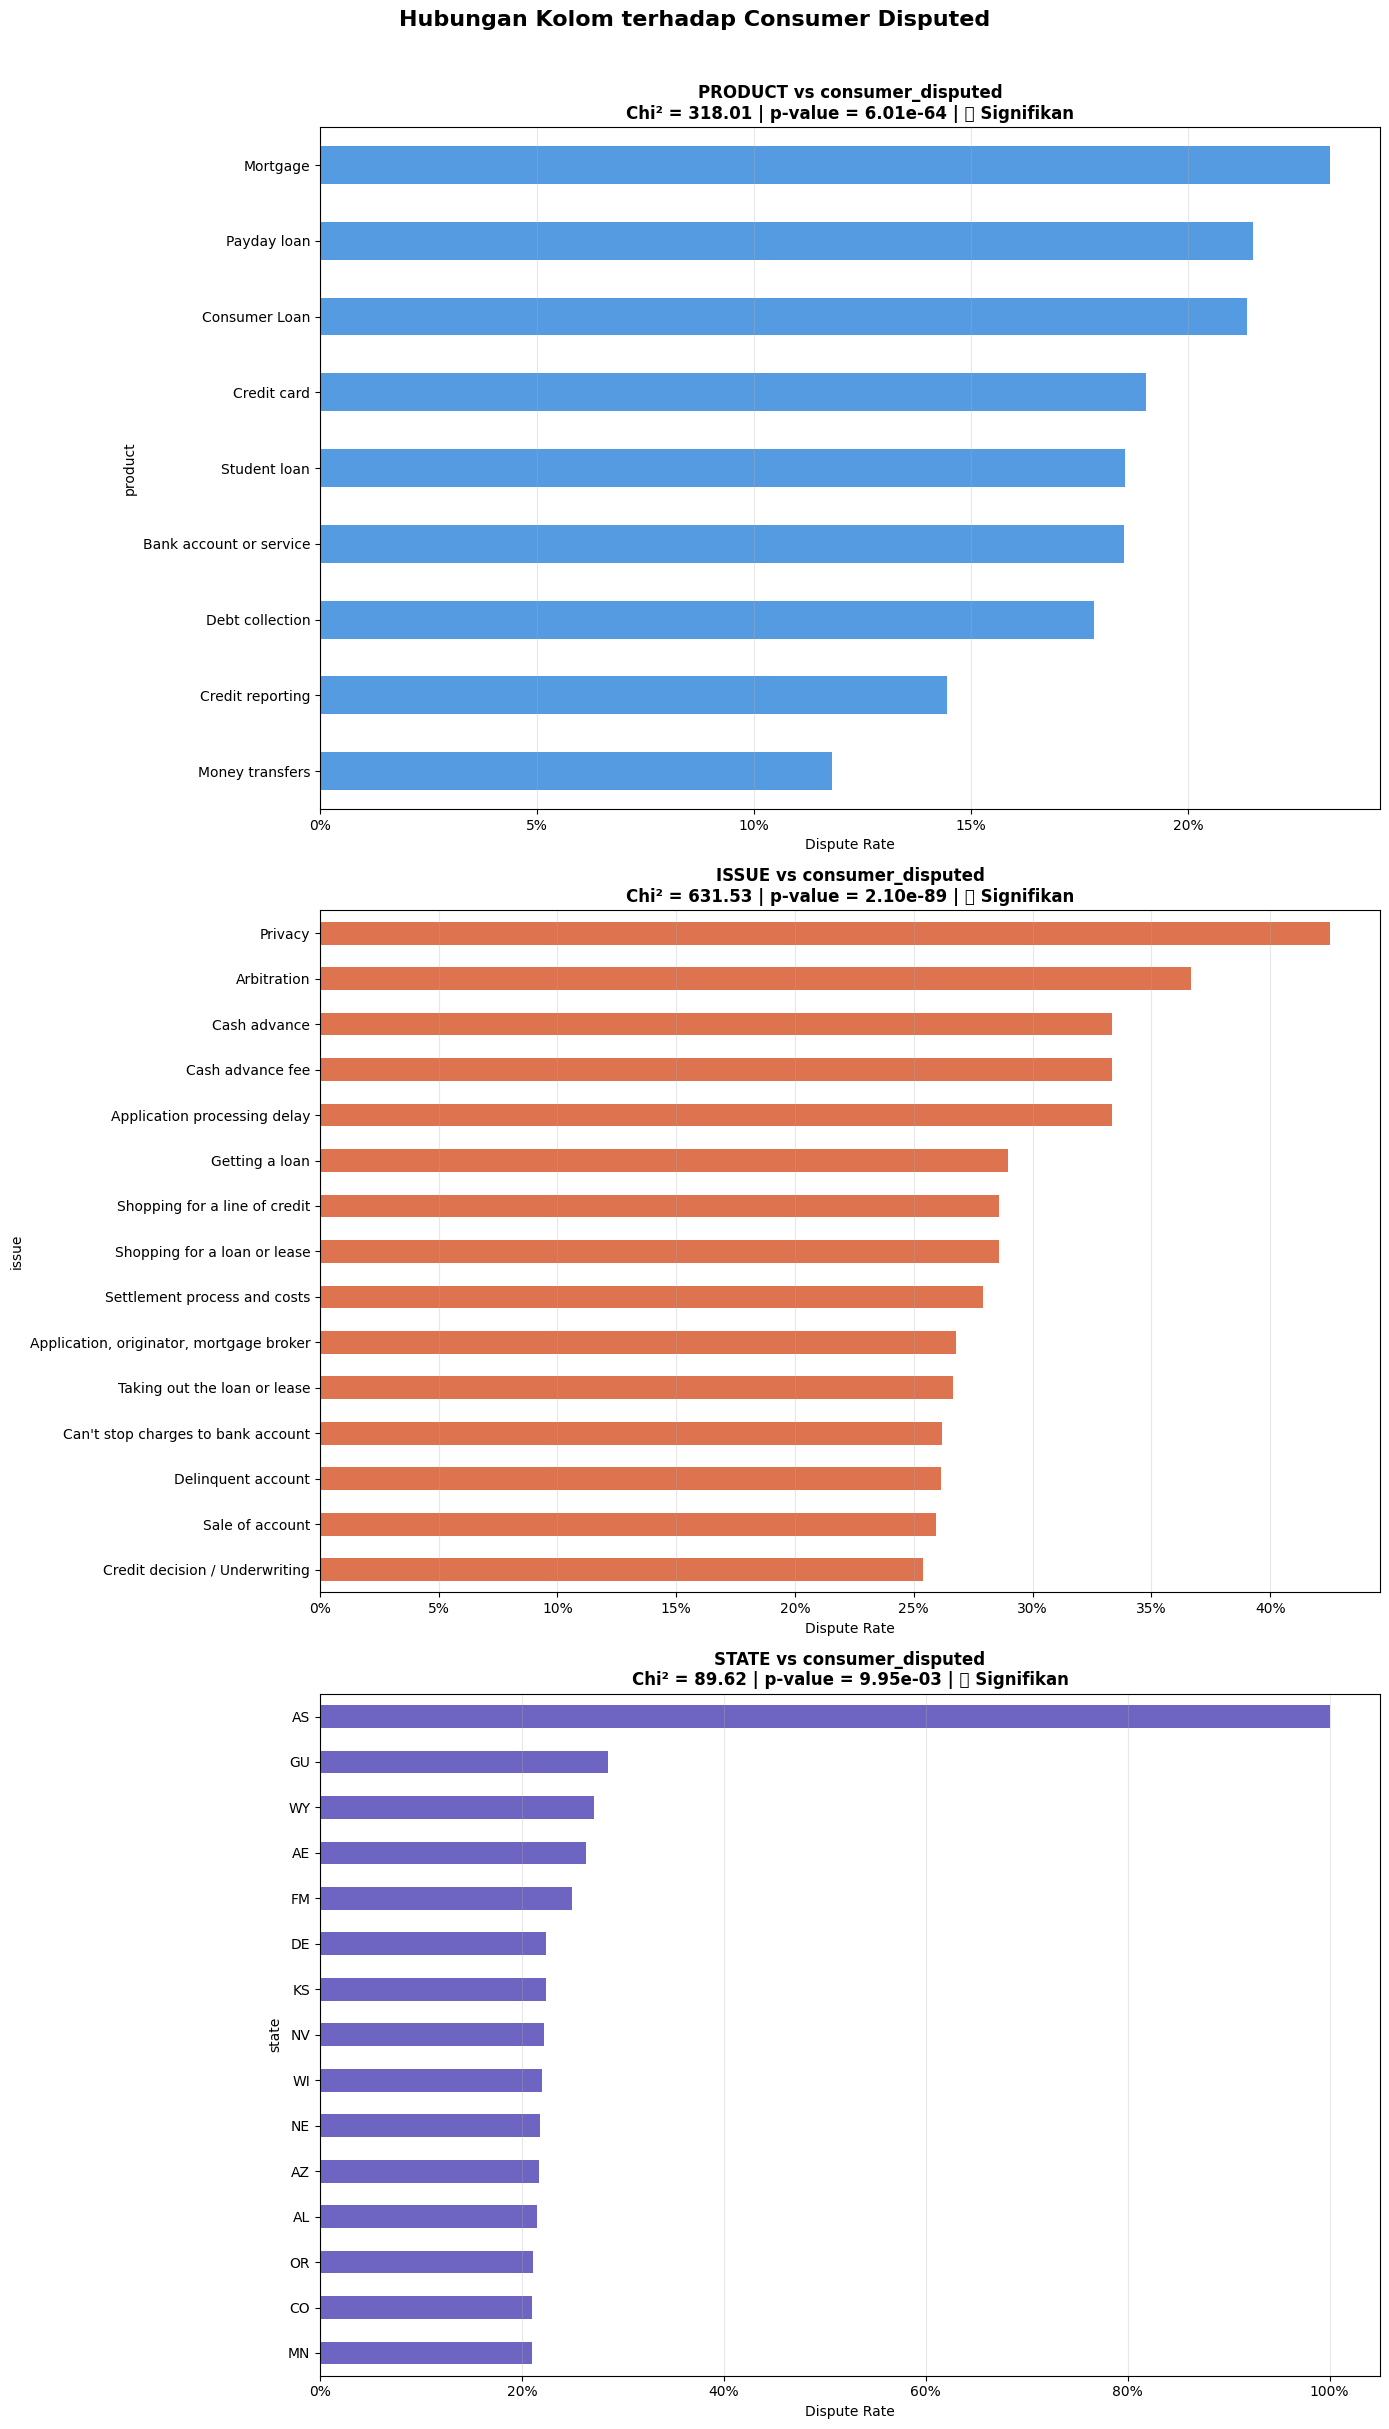

In [11]:
col = ['product', 'issue', 'state', 'company_response_to_consumer']

fig, axes = plt.subplots(3, 1, figsize=(14, 24))
fig.suptitle('Hubungan Kolom terhadap Consumer Disputed', fontsize=16, fontweight='bold', y=1.01)

colors = ['#378ADD', '#D85A30', '#534AB7']

for i, (c, ax, color) in enumerate(zip(col, axes, colors)):
    contingency = pd.crosstab(df[c], df['consumer_disputed?'])
    chi2, p_value, dof, expected = chi2_contingency(contingency)
    
    dispute_rate = (
        pd.crosstab(df[c], df['consumer_disputed?'], normalize='index')
    )
    
    if 'Yes' in dispute_rate.columns:
        rate = dispute_rate['Yes']
    else:
        rate = dispute_rate.iloc[:, -1]
    
    if c in ['issue', 'state']:
        rate = rate.sort_values(ascending=False).head(15)
    
    rate.sort_values().plot(kind='barh', ax=ax, color=color, alpha=0.85)
    
    ax.set_title(
        f'{c.upper()} vs consumer_disputed\nChi² = {chi2:,.2f} | p-value = {p_value:.2e} | {"✅ Signifikan" if p_value < 0.05 else "❌ Tidak Signifikan"}',
        fontsize=12, fontweight='bold'
    )
    ax.set_xlabel('Dispute Rate', fontsize=10)
    ax.set_ylabel(c, fontsize=10)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('chi2_subplot.png', dpi=150, bbox_inches='tight')
plt.show()

**Tujuan:**  
Analisis ini bertujuan untuk mengetahui apakah terdapat hubungan yang signifikan antara variabel Issue, State, dan Company Response to Consumer terhadap status Consumer Disputed. Karena seluruh variabel bersifat kategorikal, digunakan Chi-Square Test of Independence untuk menguji apakah distribusi sengketa konsumen berbeda pada masing-masing kategori.

**Hasil:**  
- Nilai p-value yang sangat kecil (< 0.05) menunjukkan bahwa jenis masalah (issue) memiliki hubungan yang signifikan dengan status sengketa konsumen.
- Nilai p-value juga jauh di bawah 0.05 sehingga terdapat hubungan signifikan antara lokasi konsumen (state) dan status dispute
- Variabel ini memiliki Chi-Square terbesar (7961.70).
- Menunjukkan bahwa jenis respons yang diberikan perusahaan sangat berkaitan dengan apakah konsumen akhirnya melakukan dispute atau tidak

## **Feature Engineering**

In [11]:
# Set threshold missing value 25%
# Drop column with missing value > threshold

threshold = 0.25
col = df.columns

for i in range(len(col)):
    if df[col[i]].isna().sum() == 0:
        continue
    else:
        col_missing = df[col[i]].isna().sum() / len(df)
        # print(col_missing)
        if col_missing > threshold:
            df = df.drop(columns=[col[i]])    

df.shape

(50000, 12)

In [12]:
# drop kolom complaint_id zipcode
# kolom complaint_id hanya sebagai identifier bukan nilai yang memiliki pengaruh terhadap atribut lain
# kolom zipcode sudah terwakilkan oleh kolom state
df = df.drop(columns=['complaint_id','zipcode'])

In [13]:
# cek data duplicate
print(f'Total data duplicate sebelum ditangani: {df.duplicated().sum()}')

# drop data duplicate
# df = df.drop_duplicates()
# print(f'Total data duplicate sesudah ditangani: {df.duplicated().sum()}')

Total data duplicate sebelum ditangani: 944


In [14]:
# Merubah nama dari kolom target
df = df.rename(columns={'consumer_disputed?':'consumer_disputed'})

In [15]:
# change the value of timely_response and consumer_disputed from yes and no to yes = 1 and no = 0
df[['consumer_disputed']] = df[['consumer_disputed']].replace("Yes",'1').replace("No","0").astype(int)
df.head()

,date_received,product,issue,company,state,submitted_via,date_sent_to_company,company_response_to_consumer,timely_response,consumer_disputed
0,08/30/2013,Mortgage,"Loan modification,collection,foreclosure",U.S. Bancorp,CA,Referral,09/03/2013,Closed with explanation,Yes,1
1,08/30/2013,Mortgage,"Loan servicing, payments, escrow account",Wells Fargo & Company,CA,Referral,09/03/2013,Closed with explanation,Yes,1
2,08/30/2013,Credit reporting,Incorrect information on credit report,Wells Fargo & Company,NY,Postal mail,09/18/2013,Closed with explanation,Yes,0
3,08/30/2013,Student loan,Repaying your loan,"Navient Solutions, Inc.",MD,Email,08/30/2013,Closed with explanation,Yes,1
4,08/30/2013,Debt collection,False statements or representation,Resurgent Capital Services L.P.,GA,Web,08/30/2013,Closed with explanation,Yes,1


In [16]:
df.to_csv('dataset_final.csv', index=False)

#### Feature Creation

In [17]:
'''
    Pada proses feature creation di tambahkan beberapa kolom
    numerik.
'''
# change the dtype of date_received and date_sent_to_company to datetime
df.date_received = pd.to_datetime(df.date_received)
df.date_sent_to_company = pd.to_datetime(df.date_sent_to_company)

# create new feature from date_received and date_sent_to_company
df['response_days'] = (df.date_sent_to_company  - df.date_received).dt.days
df['received_day'] = df.date_received.dt.day
df['received_week'] = df.date_received.dt.isocalendar().week.astype(int)
df['received_month'] = df.date_received.dt.month
df['month_in_quarter'] = df.date_received.dt.quarter

# drop date_received and date_sent_to_company
df = df.drop(columns=['date_received','date_sent_to_company'])
df.head()

,product,issue,company,state,submitted_via,company_response_to_consumer,timely_response,consumer_disputed,response_days,received_day,received_week,received_month,month_in_quarter
0,Mortgage,"Loan modification,collection,foreclosure",U.S. Bancorp,CA,Referral,Closed with explanation,Yes,1,4,30,35,8,3
1,Mortgage,"Loan servicing, payments, escrow account",Wells Fargo & Company,CA,Referral,Closed with explanation,Yes,1,4,30,35,8,3
2,Credit reporting,Incorrect information on credit report,Wells Fargo & Company,NY,Postal mail,Closed with explanation,Yes,0,19,30,35,8,3
3,Student loan,Repaying your loan,"Navient Solutions, Inc.",MD,Email,Closed with explanation,Yes,1,0,30,35,8,3
4,Debt collection,False statements or representation,Resurgent Capital Services L.P.,GA,Web,Closed with explanation,Yes,1,0,30,35,8,3


#### Spliting Data

In [18]:
X = df.drop('consumer_disputed', axis=1)
y = df['consumer_disputed']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

#### Pipeline 

In [19]:
col_num = X_train.select_dtypes(include='number').columns
col_cat = X_train.select_dtypes(include='object').columns

##### 1. Pipe Line Numerical

In [20]:
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('outlier', Winsorizer(capping_method='quantiles', tail='both', fold=0.05)),
    ('scaler', StandardScaler())
])

num_pipe_boost = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('outlier', Winsorizer(capping_method='quantiles', tail='both', fold=0.05))
])

##### 2. Pipeline Categorycal

In [21]:
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='constant',fill_value='Unknown')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

##### 3. Pipeline Transformer

In [22]:
preprocessor = ColumnTransformer([
    ('num', num_pipe, col_num),
    ('cat', cat_pipe, col_cat)
])

preprocessor_boost = ColumnTransformer([
    ('num', num_pipe_boost, col_num),
    ('cat', cat_pipe, col_cat)
])

##### 4. Pipeline Model

In [23]:
# KNN
pipe_knn = Pipeline([
    ('preprocessor',preprocessor),
    ('model', KNeighborsClassifier(n_neighbors=3) )
])

# Random Forest
pipe_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        random_state=42
    ))
])

# SVM
pipe_svm = Pipeline([
    ('preprocessor', preprocessor),
    ('model', SVC(random_state=42)) 
])

# Decission Tree
pipe_dt = Pipeline([
    ('preprocessor',preprocessor),
    ('model', DecisionTreeClassifier(random_state=42,class_weight='balanced'))
])

# Boosting
pipe_xgboost = Pipeline([
    ('preprocessor',preprocessor_boost),
    ('model', XGBClassifier(random_state=42))
])


## **Model Definition** 

In [24]:
models = {
    'KNN':pipe_knn,
    'Random Forest': pipe_rf,
    'SVM': pipe_svm,
    'Decision Tree': pipe_dt,
    'XGboost': pipe_xgboost
}

## **Model Train**

In [25]:
trained_models = {}
for model_name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[model_name] = model
    print(f"{model_name} selesai dilatih")

KNN selesai dilatih
Random Forest selesai dilatih
SVM selesai dilatih
Decision Tree selesai dilatih
XGboost selesai dilatih


## **Model Evaluation**

In [26]:
classification_results = []
for model_name, model in trained_models.items():
    y_pred = model.predict(X_test)
    report = classification_report(y_test, y_pred, output_dict=True)
    classification_results.append({
        "Model": model_name,
        "Precision": report["1"]["precision"],
        "Recall": report["1"]["recall"],
        "F1-Score": report["1"]["f1-score"],
        "Accuracy": report["accuracy"]
    })

df_results = pd.DataFrame(classification_results).set_index("Model").round(4)
df_results.reset_index().sort_values("F1-Score", ascending=False)

,Model,Precision,Recall,F1-Score,Accuracy
3,Decision Tree,0.2425,0.2899,0.2641,0.6890
0,KNN,0.2593,0.1564,0.1951,0.7516
1,Random Forest,0.3163,0.0483,0.0838,0.7967
4,XGboost,0.3333,0.0078,0.0152,0.8060
2,SVM,0.0000,0.0000,0.0000,0.8075


#### Hasil train dengan Cross Validation

In [ ]:
''' 
    Proses training model menggunakan cross validation score
    dengan parameter scoring = f1
'''
cv_results = []
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for model_name, model in trained_models.items():
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=skf,
        scoring='f1',
        n_jobs=1
    )

    print(f'{model_name} selesai dilatih')

    cv_results.append({
        'Model': model_name,
        'Mean_CV_Score': scores.mean(),
        'Std_CV_Score': scores.std()
    })

cv_results = pd.DataFrame(cv_results)

best_cv_model = cv_results.sort_values(
    by='Mean_CV_Score',
    ascending=False
)

display(best_cv_model)

print(
    f"Model terbaik adalah "
    f"{best_cv_model['Model'].iloc[0]} "
    f"dengan score: "
    f"{best_cv_model['Mean_CV_Score'].iloc[0]:.4f}"
)

KNN selesai dilatih
Random Forest selesai dilatih
SVM selesai dilatih
Decision Tree selesai dilatih
XGboost selesai dilatih


,Model,Mean_CV_Score,Std_CV_Score
3,Decision Tree,0.251414,0.012985
0,KNN,0.200207,0.005921
1,Random Forest,0.078070,0.007390
4,XGboost,0.015481,0.004440
2,SVM,0.000000,0.000000


Model terbaik adalah Decision Tree dengan score: 0.2514


**Insight Singkat:**  

Berdasarkan hasil 5-Fold Cross Validation menggunakan metrik F1-Score, Decision Tree memperoleh skor rata-rata tertinggi sebesar 0.2514 dengan standar deviasi 0.0130. Nilai standar deviasi yang rendah menunjukkan performa model yang relatif stabil pada setiap fold. Oleh karena itu, Decision Tree dipilih sebagai kandidat model terbaik untuk dilanjutkan ke tahap Hyperparameter Tuning. Sementara itu, Random Forest, XGBoost, dan SVM menunjukkan performa yang jauh lebih rendah karena kesulitan dalam mengidentifikasi kelas dispute yang merupakan kelas minoritas pada dataset.  




#### Hyper Parameter Tuning

In [28]:
param_grid = {
    'model__max_depth'         : [5,10,None],
    'model__min_samples_split' : [2,5,10],
    'model__min_samples_leaf'  : [1,2,4],
    'model__criterion'         : ['gini','entropy']
}

tuning = GridSearchCV(
    estimator= trained_models[best_cv_model.Model.iloc[0]],
    param_grid = param_grid,
    cv = 5,
    scoring = 'f1',
    n_jobs = 1
)

tuning.fit(X_train,y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('outlier',
                                                                                          Winsorizer(capping_method='quantiles',
                                                                                                     fold=0.05,
                                                                                                     tail='both')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         Index(['response_days', 'received_day', 'received_week', 'received_month',
       'month_in_quarte...
                                                                         Index(['product', 'issue', 'company', 'state', 'submitted_via',
       'company_response_to_consumer', 'timely_response'],
      dtype='object'))])),
                                       ('model',
                                        DecisionTreeClassifier(class_weight='balanced',
                                                               random_state=42))]),
             n_jobs=1,
             param_grid={'model__criterion': ['gini', 'entropy'],
                         'model__max_depth': [5, 10, None],
                         'model__min_samples_leaf': [1, 2, 4],
                         'model__min_samples_split': [2, 5, 10]},
             scoring='f1')

In [29]:
#  Cek parameter terbaik
for param, result in tuning.best_params_.items():
    print(f'{param} : {result}')

model__criterion : entropy
model__max_depth : 10
model__min_samples_leaf : 4
model__min_samples_split : 10


In [30]:
# Perbandingan sebelum dan sesudah dilakukan hyper parameter tuning
best_score_before = best_cv_model.Mean_CV_Score.iloc[0]
best_score_after = tuning.best_score_

print(f'Sebelum dilakukakan hyper parameter tuning: {best_score_before:.4f}')
print(f'Sesudah dilakukakan hyper parameter tuning: {best_score_after:.4f}')

Sebelum dilakukakan hyper parameter tuning: 0.2514
Sesudah dilakukakan hyper parameter tuning: 0.3564


**Insight:**  

Hasil Cross Validation menunjukkan bahwa model Decision Tree baseline memperoleh rata-rata F1-Score sebesar 0.2514. Setelah dilakukan Hyperparameter Tuning menggunakan GridSearchCV, skor meningkat menjadi 0.3564. Peningkatan sebesar 0.1050 poin atau sekitar 41.8% menunjukkan bahwa kombinasi hyperparameter yang dipilih mampu meningkatkan kemampuan model dalam mendeteksi complaint yang berpotensi menjadi dispute.

In [31]:
best_model = tuning.best_estimator_

y_pred_train = best_model.predict(X_train)
y_pred_test = best_model.predict(X_test)

In [45]:
# Probability that the consumer status would be disputed
success_prob = best_model.predict_proba(X_test)[:, 1]

results = X_test.copy()

results['Company_Name'] = df.loc[X_test.index, 'company']
results['Actual'] = y_test
results['Predicted'] = y_pred_test
results['Disputed Probability'] = success_prob

top_hidden_gems = results[results['Predicted'] == 1]

top_hidden_gems = top_hidden_gems.sort_values(
    by='Disputed Probability',
    ascending=False
)

sort = top_hidden_gems[
    ['Company_Name','Actual','Predicted', 'Disputed Probability']
]
sort.groupby('Company_Name').agg({
    'Disputed Probability':'mean'
}).reset_index().sort_values(by='Disputed Probability', ascending=False)

,Company_Name,Disputed Probability
8,"AR Resources, Inc.",0.954492
316,MOHELA,0.758810
346,"NIC, Inc.",0.749768
326,"Medical Data Systems, Inc.",0.721421
263,Hollis Cobb Associates,0.721421
...,...,...
217,FirstBank,0.501628
420,Rabobank,0.501628
224,"Focused Recovery Solutions, Inc.",0.501628
338,Mortgage Investors Corporation,0.501628


              precision    recall  f1-score   support

           0       0.90      0.40      0.56     32300
           1       0.25      0.81      0.38      7700

    accuracy                           0.48     40000
   macro avg       0.57      0.61      0.47     40000
weighted avg       0.77      0.48      0.52     40000

              precision    recall  f1-score   support

           0       0.89      0.39      0.54      8075
           1       0.24      0.79      0.36      1925

    accuracy                           0.47     10000
   macro avg       0.56      0.59      0.45     10000
weighted avg       0.76      0.47      0.51     10000



<Figure size 600x500 with 0 Axes>

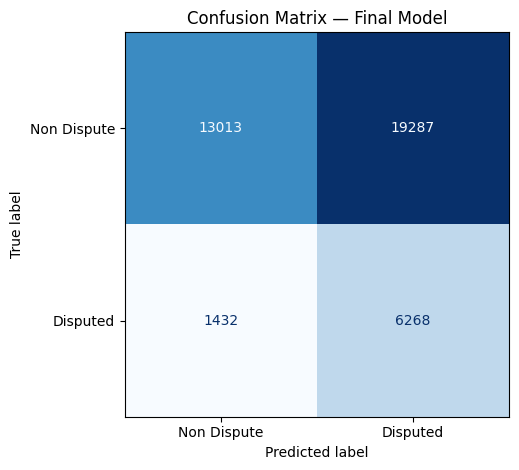

<Figure size 600x500 with 0 Axes>

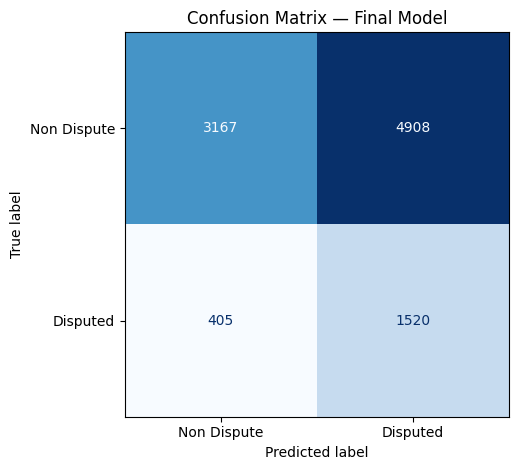

In [41]:
print(classification_report(y_train, y_pred_train))

print(classification_report(y_test,y_pred_test))

cm = confusion_matrix(y_train, y_pred_train)

plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                            display_labels=["Non Dispute", "Disputed"])
disp.plot(cmap="Blues", colorbar=False)
plt.title("Confusion Matrix — Final Model")
plt.tight_layout()
plt.show()

cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                            display_labels=["Non Dispute", "Disputed"])
disp.plot(cmap="Blues", colorbar=False)
plt.title("Confusion Matrix — Final Model")
plt.tight_layout()
plt.show()

**Insight:**  
Model memperoleh F1-score 0.37 pada kelas dispute, yang menunjukkan bahwa model sudah cukup mampu mengidentifikasi complaint yang berpotensi menjadi dispute, meskipun masih terdapat ruang untuk peningkatan performa. Karena F1-score mempertimbangkan precision dan recall secara bersamaan, metrik ini dipilih sebagai indikator utama dalam mengevaluasi model pada dataset yang tidak seimbang.

## **Model Saving**

In [35]:
joblib.dump(
    best_model,
    'best_model.pkl'
)

['best_model.pkl']